#  🏏 IPL Data Analysis

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#  📂 Data Loading

In [2]:
match = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

# 🧹 Data Cleaning

In [3]:
match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [4]:
match.isnull().mean()*100

id                  0.000000
season              0.000000
city                4.657534
date                0.000000
match_type          0.000000
player_of_match     0.456621
venue               0.000000
team1               0.000000
team2               0.000000
toss_winner         0.000000
toss_decision       0.000000
winner              0.456621
result              0.000000
result_margin       1.735160
target_runs         0.273973
target_overs        0.273973
super_over          0.000000
method             98.082192
umpire1             0.000000
umpire2             0.000000
dtype: float64

In [5]:
# droping Method column as it contain  98.082192% null values
match.drop(columns=['method'],inplace=True)

In [6]:
#Filling the mising value in city columns when ipl was held in Dubai due to covid-19
match[match['city'].isnull()]
match['city'].fillna('Dubai',inplace = True)

In [7]:
# Imputing missing value in winner & player_of_match columns when there was no result
match[match['winner'].isnull()]
match['winner'].fillna('No result',inplace = True)
match['player_of_match'].fillna('No result',inplace = True)

In [8]:
#imputting missing values in result_margin as -1 when there was super-over and no result
match[match['result_margin'].isnull()]
match['result_margin'].fillna(-1,inplace = True)

In [9]:
#imputting missing values in result_margin as -1 when there was  no result
match[match['target_runs'].isnull()]
match['target_runs'].fillna(-1,inplace = True)
match['target_overs'].fillna(-1,inplace = True)

In [10]:
#removing city names from venue
match['venue'] = match['venue'].str.split(',').str[0].str.strip()
match['venue'] = match['venue'].str.replace('.', '', regex=False)

In [11]:
#standarzing names of Stadium
venue_map = {
    'MChinnaswamy Stadium': 'M Chinnaswamy Stadium',
    
    'Punjab Cricket Association Stadium': 'Punjab Cricket Association IS Bindra Stadium',
    
    'Sardar Patel Stadium': 'Narendra Modi Stadium',
    
    'Zayed Cricket Stadium': 'Sheikh Zayed Stadium',
    
    'Dr YS Rajasekhara Reddy ACA-VDCA Cricket Stadium': 
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
}
match['venue'] = match['venue'].replace(venue_map)

In [12]:
match.isnull().mean()*100

id                 0.0
season             0.0
city               0.0
date               0.0
match_type         0.0
player_of_match    0.0
venue              0.0
team1              0.0
team2              0.0
toss_winner        0.0
toss_decision      0.0
winner             0.0
result             0.0
result_margin      0.0
target_runs        0.0
target_overs       0.0
super_over         0.0
umpire1            0.0
umpire2            0.0
dtype: float64

In [13]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [14]:
deliveries.isnull().mean()*100

match_id             0.000000
inning               0.000000
batting_team         0.000000
bowling_team         0.000000
over                 0.000000
ball                 0.000000
batter               0.000000
bowler               0.000000
non_striker          0.000000
batsman_runs         0.000000
extra_runs           0.000000
total_runs           0.000000
extras_type         94.586463
is_wicket            0.000000
player_dismissed    95.036793
dismissal_kind      95.036793
fielder             96.414993
dtype: float64

In [15]:
#imputing extras_type coloumn with 'No_extras' when there was no extra runs
deliveries[deliveries['extras_type'].isnull()]
deliveries['extras_type'].fillna('No_extras',inplace = True)

In [16]:
#imputing player_dismissed coloumn with 'No_wicket' when there was no dismissal
deliveries['player_dismissed'].fillna('No_wicket',inplace = True)

In [17]:
#imputing dismissal_kind coloumn with 'No_dismissal' when there was no fall of wicket
deliveries['dismissal_kind'].fillna('No_dismissal',inplace = True)

In [18]:
#imputing fielder coloumn witn 'No_involvement' where there is no involvement of the fielder
deliveries[deliveries['fielder'].isnull()]
deliveries['fielder'].fillna('No_involvement',inplace = True)

In [19]:
deliveries.isnull().mean()*100

match_id            0.0
inning              0.0
batting_team        0.0
bowling_team        0.0
over                0.0
ball                0.0
batter              0.0
bowler              0.0
non_striker         0.0
batsman_runs        0.0
extra_runs          0.0
total_runs          0.0
extras_type         0.0
is_wicket           0.0
player_dismissed    0.0
dismissal_kind      0.0
fielder             0.0
dtype: float64

# EDA

# Team Performance Analysis

#### Which team has the highest number of wins across all seasons?

In [20]:
win = match['winner'].value_counts().head(5)
print('The team highest number of win across all seasons: ',win.idxmax(),'with',win.max())

The team highest number of win across all seasons:  Mumbai Indians with 144


#### chart showing total wins for top 5 team.

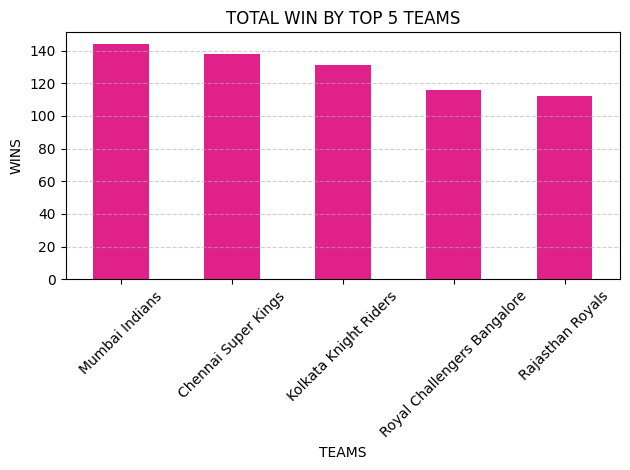

In [21]:
win.plot(kind= 'bar',color='#e0218a')
plt.title('TOTAL WIN BY TOP 5 TEAMS')
plt.xlabel('TEAMS')
plt.xticks(rotation=45)
plt.ylabel('WINS')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Which teams perform better when batting first or chasing?


In [22]:
decision = match.groupby('toss_decision')
team_performance = decision['winner'].value_counts()
team_performance

toss_decision  winner                     
bat            Chennai Super Kings            63
               Mumbai Indians                 54
               Kolkata Knight Riders          50
               Rajasthan Royals               43
               Royal Challengers Bangalore    37
               Sunrisers Hyderabad            30
               Delhi Daredevils               29
               Kings XI Punjab                24
               Deccan Chargers                14
               Delhi Capitals                 13
               Gujarat Titans                  9
               Pune Warriors                   9
               Lucknow Super Giants            6
               Punjab Kings                    4
               Gujarat Lions                   2
               Rising Pune Supergiants         2
               No result                       1
               Royal Challengers Bengaluru     1
field          Mumbai Indians                 90
               Kolkata Kni

# Player Performance Analysis


#### Who are the top 10 run-scorers across all seasons?

In [44]:
batsmen = deliveries.groupby('batter')
top_10 =  batsmen['batsman_runs'].sum().sort_values(ascending = False).head(10)
top_10

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

#### Horizontal bar chart for total runs scored by players.

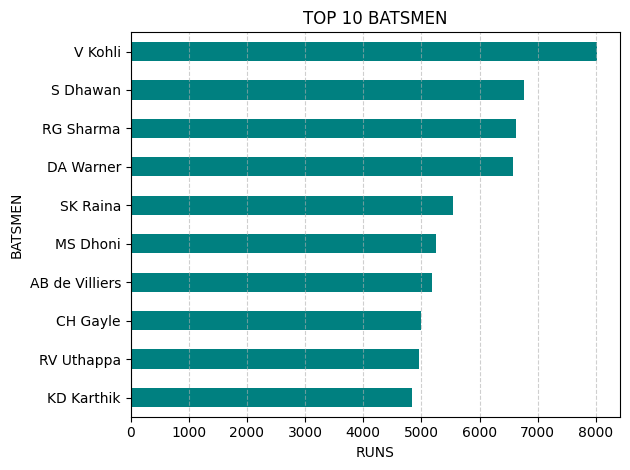

In [45]:
top_10 = top_10.sort_values(ascending=True)
top_10.plot(kind= 'barh',color='#008080' )
plt.title('TOP 10 BATSMEN')
plt.xlabel('RUNS')
plt.ylabel('BATSMEN')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Which batsman has the highest strike rate (minimum 500 runs)?


In [26]:
batsmen = deliveries.groupby('batter')
runs = batsmen['batsman_runs'].sum()
balls = batsmen['ball'].count()
sr = (runs / balls) * 100
sr = sr[runs >= 500].sort_values(ascending=False).head(10)
sr


batter
PD Salt           169.610390
TM Head           168.558952
AD Russell        164.224422
H Klaasen         161.990212
TH David          158.033573
SP Narine         155.894309
N Pooran          154.768154
LS Livingstone    154.187192
Rashid Khan       153.521127
GJ Maxwell        150.488599
dtype: float64

#### Who are the top 10 wicket-takers across all seasons?

In [27]:
bowlers = deliveries.groupby('bowler')
top_bowler = bowlers['is_wicket'].sum().sort_values(ascending = False).head(10)
top_bowler

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64

#### Bar chart showing total wickets taken by bowlers.

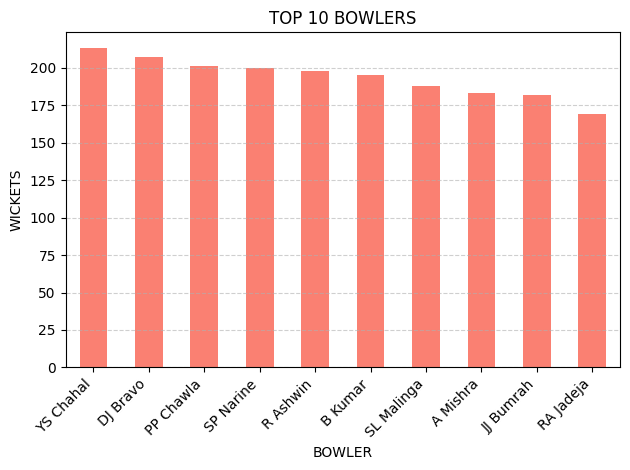

In [28]:
top_bowler.plot(kind = 'bar',color='#fa8072')
plt.xlabel("BOWLER")
plt.xticks(rotation=45, ha='right')
plt.ylabel('WICKETS')
plt.title('TOP 10 BOWLERS')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


#### Which bowlers have the best economy rates (minimum 50 overs bowled)?


In [29]:
bowler = deliveries.groupby('bowler')

runs_conceded = bowler['total_runs'].sum()
balls_bowled = bowler['ball'].count()
overs_bowled = balls_bowled / 6
economy = runs_conceded / overs_bowled
economy = economy[overs_bowled >= 50]
economy.sort_values().head(10)

bowler
A Kumble            6.646999
GD McGrath          6.674772
M Muralitharan      6.698292
J Yadav             6.738693
SP Narine           6.761216
RE van der Merwe    6.791209
DW Steyn            6.791411
DL Vettori          6.833121
Rashid Khan         6.907963
J Botha             6.922426
dtype: float64

#### Visualization: Box plot for economy rates of bowlers.

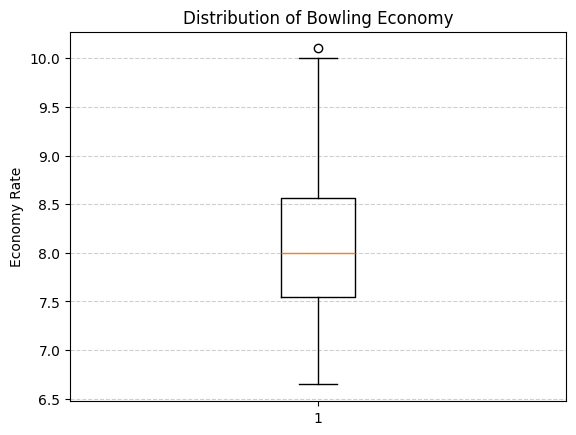

In [30]:
plt.boxplot(economy)

plt.title("Distribution of Bowling Economy")
plt.ylabel("Economy Rate")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Venue Analysis

#### Which venues have the highest average first-innings score?

In [31]:
venue = match.groupby('venue')
high_scoring1 = venue['target_runs'].mean().sort_values(ascending = False)
venue = high_scoring1.idxmax()
score = high_scoring1.max()
print(venue,score)


Himachal Pradesh Cricket Association Stadium 184.76923076923077


#### Bar chart showing top 7 highest average first-innings scorescoring venue

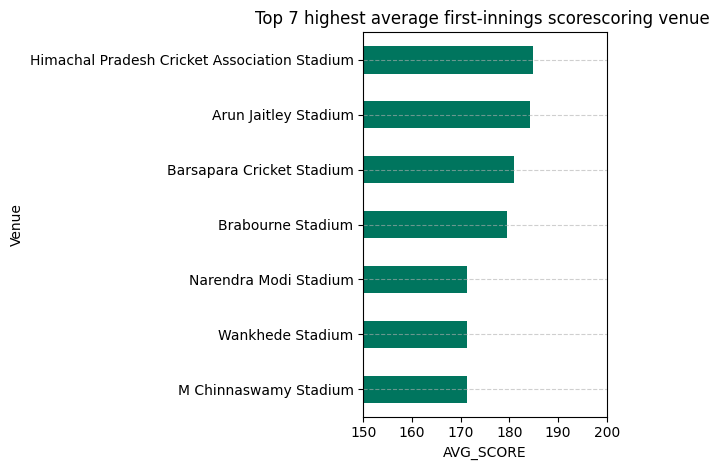

In [32]:
high_scoring1 = high_scoring1.head(7).sort_values(ascending = True)
high_scoring1.plot(kind = 'barh',color = '#00755e')
plt.xlabel("AVG_SCORE")
plt.xlim(150,200)
plt.ylabel('Venue')
plt.title('Top 7 highest average first-innings scorescoring venue ')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### Which venues see the most boundaries (fours and sixes)?

In [33]:
tempdf = deliveries[deliveries['batsman_runs'].isin([4,6])]
tempdf = tempdf.merge(match,left_on='match_id',right_on='id')
most_boundaries = tempdf.groupby('venue')['batsman_runs'].count().sort_values(ascending=False).head(10)
most_boundaries

venue
Wankhede Stadium                                5060
M Chinnaswamy Stadium                           3971
Eden Gardens                                    3882
MA Chidambaram Stadium                          3088
Rajiv Gandhi International Stadium              2951
Punjab Cricket Association IS Bindra Stadium    2442
Feroz Shah Kotla                                2296
Sawai Mansingh Stadium                          2138
Dubai International Cricket Stadium             1684
Narendra Modi Stadium                           1460
Name: batsman_runs, dtype: int64

# Match Insights

#### Does winning the toss correlate with winning the match?

In [34]:
toss = match[match['toss_winner'] == match['winner']].shape[0]
total_match = match.shape[0]
(toss/total_match)*100

50.593607305936075

####  How often do matches go to super overs, and which teams perform best in them?

In [35]:
super_over = match[match['super_over'] == 'Y'].shape[0]
print('The number of matches that has goen to super_over: ',super_over)
supper = match[match['super_over'] == 'Y']
supper['winner'].value_counts()



The number of matches that has goen to super_over:  14


winner
Kings XI Punjab                3
Delhi Capitals                 3
Rajasthan Royals               2
Mumbai Indians                 2
Royal Challengers Bangalore    2
Sunrisers Hyderabad            1
Kolkata Knight Riders          1
Name: count, dtype: int64

####  Bar chart showing super over wins by team.

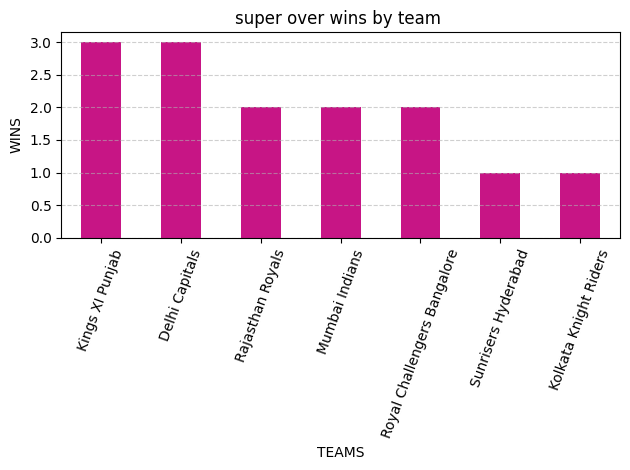

In [36]:
S_W= supper['winner'].value_counts()
S_W.plot(kind = 'bar',color = '#c71585')
plt.xlabel("TEAMS")
plt.xticks(rotation=70)
plt.ylabel('WINS')
plt.title('super over wins by team ')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Ball-by-Ball Insights

#### Which batsmen hit the most boundaries (fours and sixes)?


In [37]:
deliveries[deliveries['batsman_runs'].isin([4,6])]['batter'].value_counts().head(1)


batter
V Kohli    981
Name: count, dtype: int64

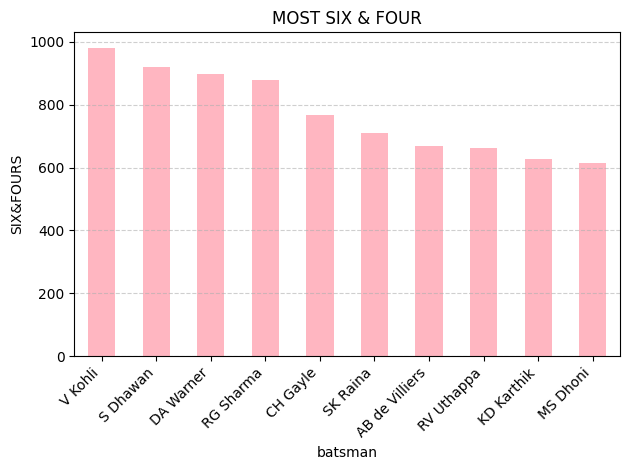

In [38]:
batsman = deliveries[deliveries['batsman_runs'].isin([4,6])]['batter'].value_counts().head(10)
batsman.plot(kind = 'bar',color = '#ffb6c1')
plt.xlabel("batsman")
plt.xticks(rotation=45, ha='right')
plt.ylabel('SIX&FOURS')
plt.title('MOST SIX & FOUR')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### Which bowlers take the most wickets in powerplay?


In [39]:
valid_wickets = deliveries[(~deliveries['dismissal_kind'].isin(['run out','retired hurt','retired out','obstructing the field','No_dismissal']))]
powerplay_wickets = valid_wickets[valid_wickets['over'] <= 6]['bowler'].value_counts().head(10)
powerplay_wickets

bowler
B Kumar           72
TA Boult          62
Sandeep Sharma    62
UT Yadav          60
I Sharma          59
DL Chahar         59
Z Khan            53
R Ashwin          51
Mohammed Shami    46
P Kumar           44
Name: count, dtype: int64

# Seasonal Comparisons

#### Find top Player of the Match in each season

In [40]:
match.groupby('season')['player_of_match'].value_counts().groupby(level=0).head(1)
                

season   player_of_match
2007/08  SE Marsh           5
2009     YK Pathan          3
2009/10  SR Tendulkar       4
2011     CH Gayle           6
2012     CH Gayle           5
2013     MEK Hussey         5
2014     GJ Maxwell         4
2015     DA Warner          4
2016     V Kohli            5
2017     BA Stokes          3
2018     Rashid Khan        4
2019     AD Russell         4
2020/21  AB de Villiers     3
2021     RD Gaikwad         4
2022     Kuldeep Yadav      4
2023     Shubman Gill       4
2024     Abhishek Sharma    3
Name: count, dtype: int64

# Player-Venue Matchups:


#### Which players perform best at specific venues runs?(batting)


In [41]:
ipl = deliveries.merge(match[['id','venue']], left_on='match_id', right_on='id')
venue_runs = ipl.groupby(['venue','batter'])['batsman_runs'].sum().reset_index()
best_batsman_venue = venue_runs.sort_values(['venue','batsman_runs'], ascending=[True,False]).drop_duplicates('venue').sort_values('batsman_runs',ascending = False)
best_batsman_venue

,venue,batter,batsman_runs
2531,M Chinnaswamy Stadium,V Kohli,3040
5547,Wankhede Stadium,RG Sharma,2295
3962,Rajiv Gandhi International Stadium,DA Warner,1623
2837,MA Chidambaram Stadium,SK Raina,1506
1295,Eden Gardens,G Gambhir,1407
4316,Sawai Mansingh Stadium,AM Rahane,1115
3844,Punjab Cricket Association IS Bindra Stadium,SE Marsh,1064
3364,Narendra Modi Stadium,Shubman Gill,953
1769,Feroz Shah Kotla,V Sehwag,933
122,Arun Jaitley Stadium,RR Pant,693


#### What are the highest run partnerships in IPL history?

In [46]:
deliveries['p1'] = np.minimum(deliveries['batter'], deliveries['non_striker'])
deliveries['p2'] = np.maximum(deliveries['batter'], deliveries['non_striker'])
patnership = deliveries.groupby(['match_id','p1','p2'])['batsman_runs'].sum().sort_values(ascending=False).head(5)
patnership

match_id  p1               p2          
980987    AB de Villiers   V Kohli         226
829795    AB de Villiers   V Kohli         209
1304112   KL Rahul         Q de Kock       208
1426297   B Sai Sudharsan  Shubman Gill    206
548372    CH Gayle         V Kohli         200
Name: batsman_runs, dtype: int64